In [21]:
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.contrib.piecewise import PiecewiseLinearFunction
from pyomo.opt import SolverFactory
from pyomo.core.base import TransformationFactory
from pyomo.opt import SolverStatus, TerminationCondition
from dataclasses import dataclass, field
from typing import Callable, List, Dict, Tuple, Optional
import numpy as np
import math
import matplotlib.pyplot as plt
import bisect
import itertools as it
from tqdm import tqdm
import csv
from pyomo.solvers.plugins.solvers.gurobi_persistent import GurobiPersistent
from typing import List, Tuple
import pandas as pd
import time
from pyomo.core.base import TransformationFactory
from pyomo.contrib.piecewise import PiecewiseLinearFunction as PLF
from mpl_toolkits.mplot3d import Axes3D  
from scipy.interpolate import griddata
from skimage.measure import marching_cubes
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import plotly.express as px
import pandas as pd, json

def read_data(name, scenario_num, plot=False, result_from_SNOG=None):
    '''
    name is data file name end in .csv
    plot control if show figures
    result_from_SNOG = [UB_SNOG, LB_SNOG] control if show SNOG result
    '''
    df = pd.read_csv(name)
    k_list = df["k"].tolist()
    LB_history = df["LB"].tolist()
    UB_history = df["UB"].tolist()
    sum_ms_list = df["sum_ms"].tolist()
    df["ms"] = df["ms"].apply(lambda x: json.loads(x) if pd.notnull(x) else None)
    df["added_nodes"] = df["added_nodes"].apply(lambda x: json.loads(x) if pd.notnull(x) else None)
    df["UB_node"] = df["UB_node"].apply(lambda x: json.loads(x) if pd.notnull(x) else None)
    df["new_nodes"] = df["new_nodes"].apply(lambda x: json.loads(x) if pd.notnull(x) else None)
    df["as_nodes"] = df["as_nodes"].apply(lambda x: json.loads(x) if pd.notnull(x) else None)
    ms_history = df["ms"].tolist()
    add_node_history = df["added_nodes"].tolist()
    UB_node_history = df["UB_node"].tolist()
    new_nodes_list = df["new_nodes"].tolist()
    as_nodes_list = df["as_nodes"].tolist()

    # if not weighted
    LB_history = [x / scenario_num for x in LB_history]
    UB_history = [x / scenario_num for x in UB_history]
    sum_ms_list = [x / scenario_num for x in sum_ms_list]

    if plot:
        plt.figure()
        plt.plot(k_list, LB_history, label="LB")
        plt.title("LB vs node_num")
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(k_list, LB_history, label="LB")
        plt.plot(k_list, UB_history, label="UB")
        if result_from_SNOG is not None:
            plt.axhline(y=result_from_SNOG[0], color="b", linestyle="--", label="UB_SNOG")
            plt.axhline(y=result_from_SNOG[1], color="r", linestyle="--", label="LB_SNOG")
        plt.title("UB, LB vs node_num")
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(k_list, sum_ms_list, label="LB sum")
        plt.title("sum_ms vs node_num")
        plt.legend()
        plt.show()

        print('sum_ms')
        for item in sum_ms_list:
            print(item)

        '''for i in range(len(ms_history[0])):
            plt.figure()
            plt.plot(k_list, [ms[i] for ms in ms_history], label="ms")
            plt.legend()
            plt.show()'''

    return k_list, LB_history, UB_history, sum_ms_list, ms_history, add_node_history, UB_node_history, new_nodes_list, as_nodes_list

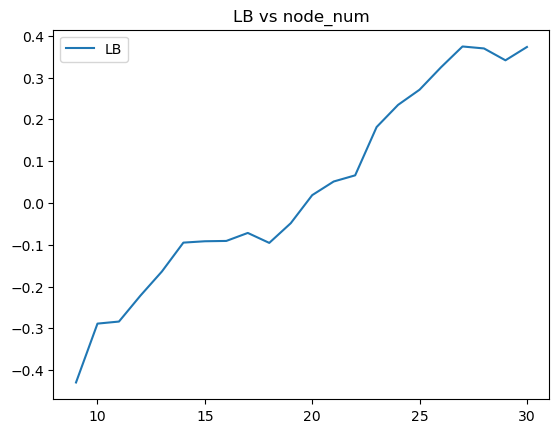

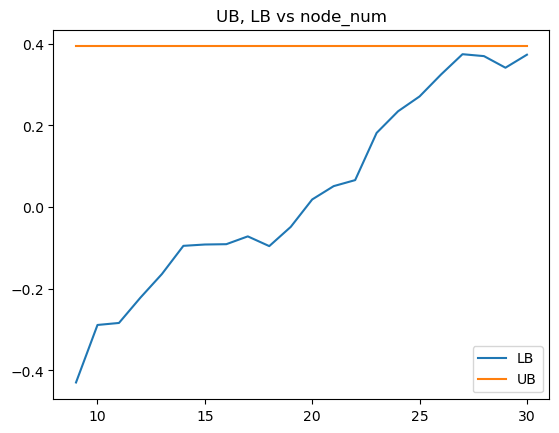

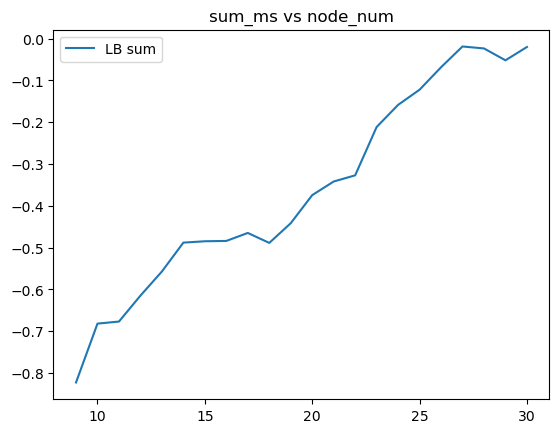

sum_ms
-0.8227763591014301
-0.6819386140600975
-0.6770345927855392
-0.6150023762753429
-0.5572455187732391
-0.48818756069194646
-0.4849245943453018
-0.4841467943008124
-0.4650107870246805
-0.488858317556343
-0.4417787306683536
-0.3745737689141738
-0.341969571848485
-0.32723600944331976
-0.21165445841515823
-0.1586113776988821
-0.1223382803544233
-0.06863978575692946
-0.01892266906095109
-0.02361315375728711
-0.05200815600634265
-0.020163535624477622


In [22]:
# "mydata1.csv"
'''
max_scenarios = 50
target_nodes = 30
bounds = {
    "x": (None, None),
    "u": (None, None),
    "e": (None, None),
    "I": (-10, 10),
    "Kp": (0, 1),
    "Ki": (0, 1),
    "Kd": (0, 1),
}
'MIPGap': 1e-1,
'NumericFocus':   1,
'Presolve':       2,
'NonConvex':      2,
'TimeLimit': 10,
'''
k_list, LB_history, UB_history, sum_ms_list, ms_history, add_node_history, UB_node_history, new_nodes_list, as_nodes_list = read_data("mydata1.csv", 50, plot=1)

In [ ]:
# "mydata2.csv"
'''
max_scenarios = 20
target_nodes = 30
bounds = {
    "x": (None, None),
    "u": (None, None),
    "e": (None, None),
    "I": (-10, 10),
    "Kp": (0, 1),
    "Ki": (0, 1),
    "Kd": (0, 1),
}
'MIPGap': 1e-2,
'NumericFocus':   1,
'Presolve':       2,
'NonConvex':      2,
'TimeLimit': 10,
'''
k_list, LB_history, UB_history, sum_ms_list, ms_history, add_node_history, UB_node_history, new_nodes_list, as_nodes_list = read_data("mydata2.csv", 20, plot=1)

In [ ]:
# "mydata3.csv" 已被覆盖
'''
max_scenarios = 50
target_nodes = 30
bounds = {
    "x": (None, None),
    "u": (None, None),
    "e": (None, None),
    "I": (-10, 10),
    "Kp": (0, 10),
    "Ki": (0, 10),
    "Kd": (0, 10),
}
'MIPGap': 1e-1,
'NumericFocus':   1,
'Presolve':       2,
'NonConvex':      2,
'TimeLimit': 1,
'''
k_list, LB_history, UB_history, sum_ms_list, ms_history, add_node_history, UB_node_history, new_nodes_list, as_nodes_list = read_data("mydata3.csv", 20, plot=1)

In [ ]:
# "mydata3.csv" 
'''
max_scenarios = 99
target_nodes = 30
bounds = {
    "x": (None, None),
    "u": (None, None),
    "e": (None, None),
    "I": (-10, 10),
    "Kp": (0, 10),
    "Ki": (0, 10),
    "Kd": (0, 10),
}
'MIPGap': 1e-1,
'NumericFocus':   1,
'Presolve':       2,
'NonConvex':      2,
'TimeLimit': 1,
'''
k_list, LB_history, UB_history, sum_ms_list, ms_history, add_node_history, UB_node_history, new_nodes_list, as_nodes_list = read_data("mydata3.csv", 20, plot=1)


In [ ]:
# "mydata4.csv" 
'''
max_scenarios = 99
target_nodes = 50
bounds = {
    "x": (None, None),
    "u": (None, None),
    "e": (None, None),
    "I": (-10, 10),
    "Kp": (0, 10),
    "Ki": (0, 10),
    "Kd": (0, 10),
}
'MIPGap': 1e-1,
'NumericFocus':   1,
'Presolve':       2,
'NonConvex':      2,
'TimeLimit': 5,
'''
k_list, LB_history, UB_history, sum_ms_list, ms_history, add_node_history, UB_node_history, new_nodes_list, as_nodes_list = read_data("mydata4.csv", 99, plot=1)